In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Dataset loading and cleaning

In [2]:
df = pd.read_csv("/Users/hadleymccormack/Desktop/AIPI/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Fixing TotalCharges (dropping rows with missing values and converting to a numeric variable)

In [3]:
# df.isna().sum()
# df[df['TotalCharges'] == ' ']

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# print(df.dtypes)
# df.isna().sum()
# print(df.shape)
df = df.dropna()
# print(df.shape)

Encoding Churn

In [4]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
# df["Churn"].value_counts()

## 2. EDA relevant to linear regression assumptions

Looking at churn by category to see which variables have noticeable differences or similarities between different groups (possible indicator of which features aren't related to churn)

In [5]:
categorical_columns = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]

for column in categorical_columns:
    print(column)
    print(df.groupby(column)["Churn"].mean())

gender
gender
Female    0.269595
Male      0.262046
Name: Churn, dtype: float64
Partner
Partner
No     0.329761
Yes    0.197171
Name: Churn, dtype: float64
Dependents
Dependents
No     0.312791
Yes    0.155312
Name: Churn, dtype: float64
PhoneService
PhoneService
No     0.250000
Yes    0.267475
Name: Churn, dtype: float64
MultipleLines
MultipleLines
No                  0.250812
No phone service    0.250000
Yes                 0.286485
Name: Churn, dtype: float64
InternetService
InternetService
DSL            0.189983
Fiber optic    0.418928
No             0.074342
Name: Churn, dtype: float64
OnlineSecurity
OnlineSecurity
No                     0.417787
No internet service    0.074342
Yes                    0.146402
Name: Churn, dtype: float64
OnlineBackup
OnlineBackup
No                     0.399417
No internet service    0.074342
Yes                    0.215670
Name: Churn, dtype: float64
DeviceProtection
DeviceProtection
No                     0.391403
No internet service    0.074342

Some variables like gender and PhoneService have very similar churn rates across their different categories, which may mean they are not related/good predictors of the churn rate of a customer. It is also of note that there is most likely multicollinearity amongst these variables since a few of the features are direct results of whether or not a customer has internet service (InternetService). This can be seen in the results above since a lot of these features (like OnlineBackup and OnlineSecurity have the exact same churn rate for the "No internet service" category).  All these variables will be kept anyways going forward with this assignment regardless. 

Correlation between numeric features:

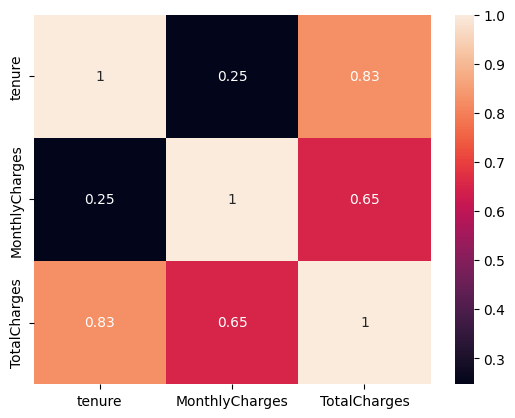

In [6]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

# Heatmap
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True)
plt.show()

The correlation coefficients concerns about multicollinearity. TotalCharges and tenure are highly correlated, and MonthlyCharges and TotalCharges are moderately correlated. This makes sense since the total amount a customer spends is a function of their tenure and monthly charges. 

In [7]:
df = df.drop(columns=["customerID"])

# Encode remaining categorical variables 
df = pd.get_dummies(df, drop_first=True)
# print(df.shape)
# print(df.dtypes)

## 3. Linear regression model code

In [8]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 4. Model performance evidence

Minimum prediction: -0.19469093751378935
Maximum prediction: 0.8442478442373917
MSE: 0.14593552097785367
R^2: 0.25221407931758133


/Users/hadleymccormack/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/hadleymccormack/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/hadleymccormack/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


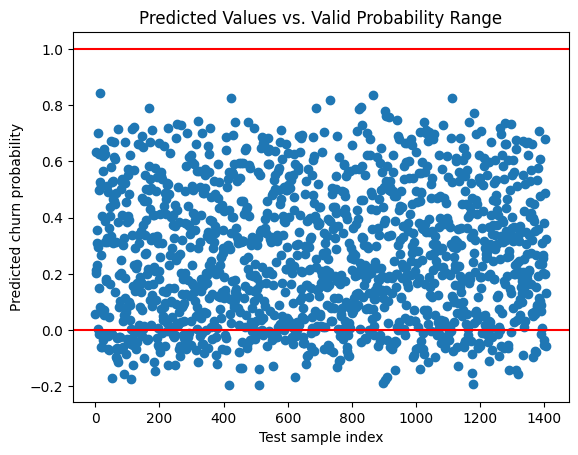

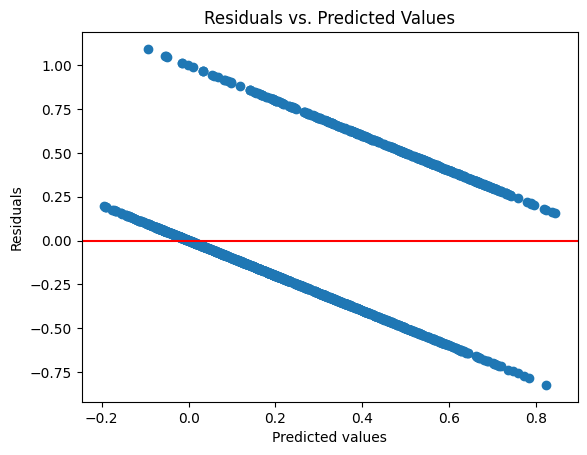

In [9]:
y_pred = model.predict(X_test)

print(f"Minimum prediction: {y_pred.min()}")
print(f"Maximum prediction: {y_pred.max()}")

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R^2: {r2}")

# Predicted values compared to probability range
plt.scatter(range(len(y_pred)), y_pred)
plt.axhline(y=0, color='red')
plt.axhline(y=1, color='red')
plt.xlabel("Test sample index")
plt.ylabel("Predicted churn probability")
plt.title("Predicted Values vs. Valid Probability Range")
plt.show()

# Residuals vs. predicted values
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")
plt.show()

The R^2 value is 0.252, which indicates that the model is a weak fit (the model only explains about 25.2% of the variance in churn).


The scatter plot of predicted values in comparison to the 0-1 range that is possible for probabilities shows that many of the predicted values are negative, which reaffirms what we saw early when looking at what the minimum of the predict churn values was. 

Looking at the plot of residuals vs. predicted values, the residuals form two straight diagonal lines, which violates the assumption that the residuals should be randomly scattered. This is another sign that linear regresson isn't a strong choice for predicting churn.


## 5. Coefficient interpretation

In [10]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

coefficients.sort_values("coefficient", ascending=False)

,feature,coefficient
10,InternetService_Fiber optic,0.273538
23,StreamingMovies_Yes,0.095261
21,StreamingTV_Yes,0.092138
9,MultipleLines_Yes,0.068537
28,PaymentMethod_Electronic check,0.062299
0,SeniorCitizen,0.054641
26,PaperlessBilling_Yes,0.035931
17,DeviceProtection_Yes,0.021537
7,PhoneService_Yes,0.021362
15,OnlineBackup_Yes,0.007571


The InternetService_Fiber optic coefficient is 0.274, meaning that customers with Fiber optic internet are about 27.4 percentage points more likely to churn than customers with DSL internet, holding all other factors constant. 

Similarly, the Contract_One year coefficient is -0.117, which indicates that customers with one year contracts are 11.7 percentage points less likely to churn than customers with the month to month contract. This effect is larger than the coefficient for the two year contract (Contract_Two year), which was -0.0746, which means that customers with the two year contract are only 7.56 percentage points less likely to churn than customers with the month to month contract. Thus, customers with one year contracts churn less than month to month customers by a larger margin than two year contract customers do, which may be a result of loyalty. 

## 6. Limitation of using linear regression for churn

One limitation is that linear regression doesn't restrict predictions to the 0-1 range that makes sense for probabilities. In this model, the predicted values for the probability of customers to churn range from -0.195 to 0.844, which is nonsensical in this context since probabilities can't be negative. Logistic regression could fix this since it uses the sigmoid function to map the predictions onto the 0-1 interval. 